[ 2.27034383  0.19040799  1.5110111  -1.20500649  1.48763894]
-0.24596258940195176
[0.21836283916779914, 0.18958099461022307, 0.17743742696227113, 0.17025440002942938, 0.1658950976830729, 0.16265029772089318, 0.1603312483231291, 0.15851669844133, 0.1573068074800111, 0.15610492425149966]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       147
           1       0.92      0.93      0.93       153

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



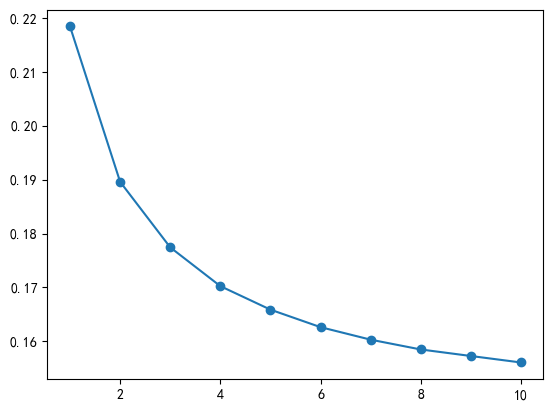

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


class MyLogisticRegression:
    def __init__(self, learning_rate=0.1, epochs=10):
        self.learning_rate = learning_rate
        self.epochs = epochs
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def compute_loss(self, X, y):
        # 第一步：计算线性回归的预测值Z（逻辑回归的线性部分）
        Z = np.dot(X, self.coef_) + self.intercept_
        # 第二步：通过sigmoid函数将Z映射到0-1之间，得到预测概率p
        p = self.sigmoid(Z)
        # 第三步：计算并返回对数损失的平均值（负的对数似然均值）
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        # 初始化系数：形状为(特征数,)，随机值
        self.coef_ = np.random.random(size=X.shape[1])
        self.intercept_ = np.random.random()
        self.loss_ = []
        # 遍历每一轮训练
        for epoch in range(self.epochs):
            # 生成随机的样本索引顺序（打乱样本，实现随机梯度下降的“随机”）
            order = np.random.permutation(X.shape[0])
            # 按打乱的顺序遍历每个样本（在线梯度下降，批量大小=1）
            for xi, yi in zip(X[order], y[order]):
                # 计算线性部分z
                z = np.dot(xi, self.coef_) + self.intercept_
                # 计算预测概率p
                p = self.sigmoid(z)
                # 更新系数：核心的梯度下降更新公式
                self.coef_ += self.learning_rate * (yi - p) * xi
                # 更新截距：梯度下降更新公式
                self.intercept_ += self.learning_rate * (yi - p)
            # 每一轮训练结束后，计算并记录当前的损失值
            loss = self.compute_loss(X, y)
            self.loss_.append(loss)
        return self
    
    def predict(self, X):
        # 第一步：计算线性预测值Z
        Z = np.dot(X, self.coef_) + self.intercept_
        # 第二步：根据Z的大小输出类别标签（1或0）
        return np.where(Z > 0, 1, 0)
    

X, y = make_classification(n_samples=1000, n_features=5, n_classes=2, random_state=2332)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=323)
lr = MyLogisticRegression(learning_rate=0.01, epochs=10)
lr.fit(X_train, y_train)
print(lr.coef_)
print(lr.intercept_)
print(lr.loss_)
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))
plt.plot(range(1, lr.epochs + 1), lr.loss_, marker="o")